In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/muskankhatoon01/ml4sci-dataset1/quark-gluon_data-set_n139306.hdf5


# Common Task 2: Jets as Graphs — Quark/Gluon Classification

## Approach Overview

This notebook implements a **Graph Neural Network (GNN)** pipeline to classify 
quark and gluon jets from the ML4SCI dataset. We follow three steps as required:

1. **Point Cloud Construction** — Extract non-zero pixels from each detector 
   channel (ECAL, HCAL, Tracks) to form a sparse point cloud
2. **Graph Representation** — Cast the point cloud into a channel-aware graph 
   with physically motivated node features, intra-channel KNN edges, 
   inter-channel edges, and 4-dimensional edge features
3. **GNN Classification** — Train a **GATv2 (Graph Attention Network v2)** 
   classifier that learns which neighboring nodes matter most via attention weights

**Model:** GATv2 with 4 layers, 8 attention heads, residual connections, 
dual pooling (mean + add), ~894K parameters

**Dataset:** Quark/Gluon jet events — 3 channels (ECAL, HCAL, Tracks), 
125×125 images, 139,306 total events

In [1]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.4 MB/s eta 0:00:0000:01


In [2]:
import torch
import h5py
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score
import networkx as nx
from torch_geometric.utils import to_networkx
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                              classification_report,
                              precision_recall_curve,
                              average_precision_score)
import matplotlib.gridspec as gridspec


In [3]:

file_path = "/kaggle/input/datasets/muskankhatoon01/ml4sci-dataset1/quark-gluon_data-set_n139306.hdf5"

NUM_SAMPLES = 40000
SEED = 42

def load_data_with_labels(h5_path, n_samples=NUM_SAMPLES, seed=SEED):
    rng = np.random.default_rng(seed)
    with h5py.File(h5_path, 'r') as f:
        total = f['X_jets'].shape[0]
        indices = np.sort(rng.choice(total, size=n_samples, replace=False))
        CHUNK = 5000
        data_chunks = []
        label_chunks = []
        
        pbar = tqdm(range(0, n_samples, CHUNK), 
                    desc="Loading from HDF5", 
                    unit="chunk",
                    bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} chunks [{elapsed}<{remaining}]")
        
        for start in pbar:
            end = min(start + CHUNK, n_samples)
            batch_idx = indices[start:end]
            data_chunks.append(f['X_jets'][batch_idx].astype(np.float32))
            label_chunks.append(f['y'][batch_idx])
            pbar.set_postfix({"loaded": f"{end:,}/{n_samples:,} events"})
        
    data   = np.concatenate(data_chunks,  axis=0)
    labels = np.concatenate(label_chunks, axis=0)
    
    perm = rng.permutation(n_samples)
    return data[perm], labels[perm]

data, labels = load_data_with_labels(file_path)
print("Data shape  :", data.shape)
print("Labels shape:", labels.shape)

Loading from HDF5:   0%|          | 0/8 chunks [00:00<?]

Data shape  : (40000, 125, 125, 3)
Labels shape: (40000,)


## Step 0: Data Loading & Normalization

The jet images contain energy deposits from three detector channels:
- **ECAL** — Electromagnetic Calorimeter (photons, electrons)
- **HCAL** — Hadronic Calorimeter (hadrons, broader deposits)  
- **Tracks** — Charged particle trajectories

Raw pixel values span several orders of magnitude, making training 
unstable if used directly. We apply **log normalization**:

$$x_{norm} = \frac{\log(1 + x)}{\log(1 + x_{max})}$$

`GLOBAL_MAX = 3.896232` is the global maximum intensity observed across 
the entire dataset, ensuring all normalized values lie in **[0, 1]**.

We also crop images from 125×125 → 112×112, removing the outer boundary 
pixels which are consistently zero across all events, reducing computation 
without losing any signal.

In [4]:
GLOBAL_MAX = 3.896232
norm_factor = np.log1p(GLOBAL_MAX)

data = np.log1p(data)
data = data / norm_factor

# Convert to (N, C, H, W)
data = np.transpose(data, (0, 3, 1, 2))

# Crop to 112x112
data = data[:, :, :112, :112]

print("Processed shape:", data.shape)

Processed shape: (40000, 3, 112, 112)


## Step 1: Graph Construction

### Baseline Approach (replaced)
The naive approach below builds a single KNN graph using only 2D pixel 
coordinates across all channels combined. This ignores the fact that 
ECAL, HCAL, and Tracks are physically distinct detectors — connecting 
nodes across detectors purely by pixel proximity is not physically meaningful.

### Improved: Channel-Aware Graph Construction
The function in the next cell implements a physically motivated graph:

| Component | Design Choice | Reason |
|---|---|---|
| **Nodes** | Non-zero pixels only | Sparse representation, ~500–700 nodes per jet |
| **Node features** | 9-dimensional | See breakdown below |
| **Intra-channel edges** | KNN (k=8) within same detector | Preserves detector boundaries |
| **Inter-channel edges** | k=3 cross-detector connections | Captures ECAL↔HCAL↔Tracks correlations |
| **Edge features** | 4-dimensional | Distance, Δrow, Δcol, same-channel flag |

**Node feature breakdown (9 features per node):**
1. Raw intensity
2. Log intensity — compresses dynamic range
3. Normalized row coordinate (η proxy)
4. Normalized col coordinate (φ proxy)  
5. Radial distance from jet center — encodes jet spread
6. Azimuthal angle φ from center — encodes jet shape
7. One-hot channel: ECAL
8. One-hot channel: HCAL
9. One-hot channel: Tracks

In [5]:
def build_channel_aware_graph(sample, k=8):
    C, H, W = sample.shape
    all_x, all_pos, all_channel = [], [], []
    node_offset = 0
    channel_node_ranges = []

    for c in range(C):
        channel_map = sample[c]
        coords = (channel_map > 0).nonzero(as_tuple=False)

        if coords.shape[0] == 0:
            channel_node_ranges.append((node_offset, node_offset))
            continue

        rows = coords[:, 0].float()
        cols = coords[:, 1].float()
        intensities = channel_map[coords[:, 0], coords[:, 1]]

        feat_intensity = intensities.unsqueeze(1)
        feat_log       = torch.log1p(intensities).unsqueeze(1)
        feat_row       = (rows / H).unsqueeze(1)
        feat_col       = (cols / W).unsqueeze(1)
        feat_r         = torch.sqrt(
                             ((rows - H/2)/(H/2))**2 +
                             ((cols - W/2)/(W/2))**2
                         ).unsqueeze(1)
        feat_phi       = torch.atan2(
                             rows - H/2, cols - W/2
                         ).unsqueeze(1) / 3.14159
        feat_ch_onehot = torch.zeros(coords.shape[0], 3)
        feat_ch_onehot[:, c] = 1.0

        node_feats = torch.cat([
            feat_intensity,   # 1
            feat_log,         # 1
            feat_row,         # 1
            feat_col,         # 1
            feat_r,           # 1
            feat_phi,         # 1
            feat_ch_onehot,   # 3
        ], dim=1)             # total: 9 features

        all_x.append(node_feats)
        all_pos.append(coords.float())
        all_channel.append(torch.full((coords.shape[0],), c, dtype=torch.long))
        channel_node_ranges.append((node_offset, node_offset + coords.shape[0]))
        node_offset += coords.shape[0]

    if node_offset == 0:
        return None

    x         = torch.cat(all_x,       dim=0)
    pos       = torch.cat(all_pos,     dim=0)
    ch_labels = torch.cat(all_channel, dim=0)

    #Intra-channel KNN edges 
    edge_src, edge_dst = [], []

    for c in range(C):
        start, end = channel_node_ranges[c]
        if end - start < 2:
            continue

        pos_c    = pos[start:end]
        dist     = torch.cdist(pos_c, pos_c)
        dist.fill_diagonal_(float('inf'))

        actual_k = min(k, pos_c.shape[0] - 1)
        knn_idx  = dist.topk(actual_k, largest=False).indices

        Nc  = pos_c.shape[0]
        src = torch.arange(Nc).unsqueeze(1).expand(-1, actual_k).reshape(-1) + start
        dst = knn_idx.reshape(-1) + start

        edge_src.append(src)
        edge_dst.append(dst)

    # Inter-channel edges 
    INTER_K = 3
    for c1 in range(C):
        for c2 in range(c1 + 1, C):
            s1, e1 = channel_node_ranges[c1]
            s2, e2 = channel_node_ranges[c2]
            if e1 - s1 == 0 or e2 - s2 == 0:
                continue

            pos_c1     = pos[s1:e1]
            pos_c2     = pos[s2:e2]
            cross_dist = torch.cdist(pos_c1, pos_c2)

            actual_ik  = min(INTER_K, pos_c2.shape[0])
            knn_cross  = cross_dist.topk(actual_ik, largest=False).indices

            N1  = pos_c1.shape[0]
            src = torch.arange(N1).unsqueeze(1).expand(-1, actual_ik).reshape(-1) + s1
            dst = knn_cross.reshape(-1) + s2

            edge_src += [src, dst]
            edge_dst += [dst, src]

    edge_index = torch.stack([
        torch.cat(edge_src),
        torch.cat(edge_dst)
    ], dim=0)

    # Edge features
    src_pos   = pos[edge_index[0]]
    dst_pos   = pos[edge_index[1]]
    delta     = dst_pos - src_pos
    dist_e    = delta.norm(dim=1, keepdim=True)
    same_ch   = (ch_labels[edge_index[0]] ==
                 ch_labels[edge_index[1]]).float().unsqueeze(1)

    edge_attr = torch.cat([dist_e, delta, same_ch], dim=1)  # (E, 4)

    return x, edge_index, edge_attr, pos

In [25]:
sample = torch.tensor(data[0], dtype=torch.float32)
label  = labels[0]

result = build_channel_aware_graph(sample, k=8)
x, edge_index, edge_attr, pos = result

graph = Data(
    x          = x,
    edge_index = edge_index,
    edge_attr  = edge_attr,
    pos        = pos,
    y          = torch.tensor(int(label), dtype=torch.long)
)

print(graph)
print(f"\nNode features shape  : {x.shape}")          # (N, 4)
print(f"Edge index shape     : {edge_index.shape}")   # (2, E)
print(f"Edge attr shape      : {edge_attr.shape}")    # (E, 4)
print(f"Label                : {label}")

# Verify channel breakdown
for c, name in enumerate(['ECAL', 'HCAL', 'Tracks']):
    n_nodes = (x[:, 6+c] == 1).sum().item()
    print(f"  {name} nodes: {n_nodes}")

Data(x=[692, 9], edge_index=[2, 8758], edge_attr=[8758, 4], y=0, pos=[692, 2])

Node features shape  : torch.Size([692, 9])
Edge index shape     : torch.Size([2, 8758])
Edge attr shape      : torch.Size([8758, 4])
Label                : 0.0
  ECAL nodes: 70
  HCAL nodes: 397
  Tracks nodes: 225


## Step 2: Build Full Graph Dataset

The sanity check above confirms our graph structure is correct. We now 
build graphs for all 40,000 events and save to disk so we never need 
to rebuild during the same session.

**Expected per-graph statistics:**
- ~500–800 nodes (varies per jet energy)
- ~6,000–10,000 edges (intra + inter channel)
- Node feature matrix: (N, 9)
- Edge feature matrix: (E, 4)

In [7]:
NUM_GRAPH_SAMPLES = 40000

data_subset = data[:NUM_GRAPH_SAMPLES]
labels_subset = labels[:NUM_GRAPH_SAMPLES]

print("Using samples:", len(data_subset))

Using samples: 40000


In [8]:
graph_list = []
skipped    = 0

for i in tqdm(range(len(data_subset)), desc="Building graphs"):
    sample = torch.tensor(data_subset[i], dtype=torch.float32)
    label  = int(labels_subset[i])

    result = build_channel_aware_graph(sample, k=8)
    if result is None:
        skipped += 1
        continue

    x, edge_index, edge_attr, pos = result

    graph = Data(
        x          = x,
        edge_index = edge_index,
        edge_attr  = edge_attr,
        pos        = pos,
        y          = torch.tensor(label, dtype=torch.long)
    )
    graph_list.append(graph)

print(f"Graphs built: {len(graph_list)} | Skipped: {skipped}")
torch.save(graph_list, "jet_graphs_channel_aware.pt")

Building graphs:   0%|          | 0/40000 [00:00<?, ?it/s]

Graphs built: 40000 | Skipped: 0


In [4]:
graph_list = torch.load("jet_graphs_channel_aware.pt",weights_only = False)
print("Total graphs:", len(graph_list))

Total graphs: 40000


## Step 3: Train / Validation / Test Split

We use a strict **80 / 10 / 10** split:

| Split | Size | Purpose |
|---|---|---|
| Train | ~32,000 | Model training |
| Validation | ~4,000 | Hyperparameter tuning, best checkpoint selection |
| **Test** | **~4,000** | **Final unbiased evaluation — never touched during training** |

The test set is held out completely until the very end. All model selection 
decisions (early stopping, best epoch) are made on the validation set only.

In [13]:
import os

train_val_graphs, test_graphs = train_test_split(
    graph_list, test_size=0.10, random_state=42
)


train_graphs, val_graphs = train_test_split(
    train_val_graphs, test_size=0.111, random_state=42  # 0.111 * 0.9 ≈ 0.10
)

train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True,
                          num_workers=1, pin_memory=True,
                          persistent_workers=True)
val_loader   = DataLoader(val_graphs,   batch_size=64, shuffle=False,
                          num_workers=1, pin_memory=True,
                          persistent_workers=True)
test_loader  = DataLoader(test_graphs,  batch_size=64, shuffle=False,
                          num_workers=1, pin_memory=True,
                          persistent_workers=True)

print(f"Train: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")


Train: 32004 | Val: 3996 | Test: 4000


## Step 4: Model Architecture — GATv2 Classifier

We use **Graph Attention Network v2 (GATv2)**, which improves over the 
original GAT by computing attention scores dynamically per edge rather 
than statically per node. This is critical for jets where the importance 
of neighboring nodes varies significantly based on energy and position.

### Architecture
```
Input (9 features) → Linear Projection (128-dim)
        ↓
GATv2 Layer 1  [128 → 128, 8 heads, edge_dim=4] + Residual
        ↓
GATv2 Layer 2  [128 → 128, 8 heads, edge_dim=4] + Residual  
        ↓
GATv2 Layer 3  [128 → 128, 8 heads, edge_dim=4] + Residual
        ↓
GATv2 Layer 4  [128 → 256, 8 heads, edge_dim=4]
        ↓
Multi-scale concat [x1 || x2 || x3 || x4] → (N, 512)
        ↓
Dual Pooling: global_mean + global_add → (B, 1024)
        ↓
MLP Head: 1024 → 256 → 64 → 2 (Quark / Gluon)
```

**Key design choices:**
- **Residual connections** — prevent gradient vanishing in 4-layer depth
- **Multi-scale concat** — captures both local (layer 1) and global (layer 4) jet structure  
- **Dual pooling** — mean preserves average signal, add preserves total energy
- **Edge features in attention** — attention weights conditioned on detector 
  geometry (distance, same-channel flag)

**Training setup:**
- Optimizer: Adam (lr=1e-3, weight_decay=1e-4)
- Scheduler: CosineAnnealingLR (T_max=40, eta_min=1e-5)
- Loss: Cross-Entropy
- Batch size: 64
- Best checkpoint: saved and restored before test evaluation

In [14]:
from torch_geometric.nn import GATv2Conv, global_mean_pool, global_add_pool

class GATJetClassifier(nn.Module):
   
    def __init__(self, in_channels=9, hidden=128, heads=8, edge_dim=4):
        super().__init__()

        # Input projection
        self.input_proj = nn.Sequential(
            nn.Linear(in_channels, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU()
        )

        
        self.gat1 = GATv2Conv(hidden,          hidden // heads,
                               heads=heads, edge_dim=edge_dim,
                               dropout=0.1, concat=True)

        self.gat2 = GATv2Conv(hidden,          hidden // heads,
                               heads=heads, edge_dim=edge_dim,
                               dropout=0.1, concat=True)

        self.gat3 = GATv2Conv(hidden,          hidden // heads,
                               heads=heads, edge_dim=edge_dim,
                               dropout=0.1, concat=True)

        self.gat4 = GATv2Conv(hidden,          hidden * 2 // heads,
                               heads=heads, edge_dim=edge_dim,
                               dropout=0.1, concat=True)

        self.bn1 = nn.BatchNorm1d(hidden)
        self.bn2 = nn.BatchNorm1d(hidden)
        self.bn3 = nn.BatchNorm1d(hidden)
        self.bn4 = nn.BatchNorm1d(hidden * 2)

        # Multi-scale: hidden + hidden + hidden + hidden*2 = 512
        pool_dim = hidden + hidden + hidden + hidden * 2

        self.classifier = nn.Sequential(
            nn.Linear(pool_dim * 2, 512),    # *2 for mean+add concat
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.input_proj(x)

        # GAT layers with residual + BN
        x1 = F.relu(self.bn1(self.gat1(x,  edge_index, edge_attr)))
        x2 = F.relu(self.bn2(self.gat2(x1, edge_index, edge_attr))) + x1  # residual
        x3 = F.relu(self.bn3(self.gat3(x2, edge_index, edge_attr))) + x2  # residual
        x4 = F.relu(self.bn4(self.gat4(x3, edge_index, edge_attr)))

        # Multi-scale concat
        x_cat    = torch.cat([x1, x2, x3, x4], dim=1)   # (N, 512)

        # mean + add pooling — no max, no torch-scatter needed
        mean_out = global_mean_pool(x_cat, batch)         # (B, 512)
        add_out  = global_add_pool(x_cat,  batch)         # (B, 512)
        out      = torch.cat([mean_out, add_out], dim=1)  # (B, 1024)

        return self.classifier(out)

In [15]:
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = GATJetClassifier(in_channels=9, hidden=128, 
                              heads=8, edge_dim=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=40, eta_min=1e-5)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")
print(f"Device: {device}")

Trainable parameters: 894,594
Device: cuda


## Step 5: Training

Training runs for 40 epochs with CosineAnnealingLR decaying from 1e-3 → 1e-5.
The best model (by validation AUC) is saved as a checkpoint and restored 
before final test evaluation. Loss and AUC are logged every epoch for 
visualization.

In [16]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        out   = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss  = criterion(out, batch.y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)




In [17]:
def evaluate(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch  = batch.to(device)
            out    = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            probs  = F.softmax(out, dim=1)[:, 1]
            all_probs.append(probs.cpu())
            all_labels.append(batch.y.cpu())
    all_probs  = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()
    preds      = (all_probs > 0.5).astype(int)
    acc        = accuracy_score(all_labels, preds)
    auc        = roc_auc_score(all_labels, all_probs)
    return acc, auc

In [18]:
train_loss_history = []
val_auc_history    = []
val_acc_history    = []

EPOCHS = 40
best_auc = 0.0
best_model_state = None

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader)
    val_acc, val_auc = evaluate(model, val_loader)
    
    scheduler.step()  
    
    current_lr = optimizer.param_groups[0]['lr']

    if val_auc > best_auc:
        best_auc = val_auc
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        tag = "  ← best"
    else:
        tag = ""
    train_loss_history.append(train_loss)
    val_auc_history.append(val_auc)
    val_acc_history.append(val_acc)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d} | Loss: {train_loss:.4f} | "
              f"Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f} | "
              f"LR: {current_lr:.2e}{tag}")

model.load_state_dict(best_model_state)
print(f"\nBest Val AUC: {best_auc:.4f} — restored for test evaluation")

Epoch 01 | Loss: 0.6240 | Val Acc: 0.7012 | Val AUC: 0.7722 | LR: 9.98e-04  ← best
Epoch 05 | Loss: 0.5714 | Val Acc: 0.7242 | Val AUC: 0.7957 | LR: 9.62e-04  ← best
Epoch 10 | Loss: 0.5624 | Val Acc: 0.6804 | Val AUC: 0.7909 | LR: 8.55e-04
Epoch 15 | Loss: 0.5587 | Val Acc: 0.7292 | Val AUC: 0.8028 | LR: 6.94e-04
Epoch 20 | Loss: 0.5539 | Val Acc: 0.7290 | Val AUC: 0.8066 | LR: 5.05e-04  ← best
Epoch 25 | Loss: 0.5493 | Val Acc: 0.7330 | Val AUC: 0.8073 | LR: 3.16e-04
Epoch 30 | Loss: 0.5417 | Val Acc: 0.7392 | Val AUC: 0.8087 | LR: 1.55e-04
Epoch 35 | Loss: 0.5385 | Val Acc: 0.7322 | Val AUC: 0.8072 | LR: 4.77e-05
Epoch 40 | Loss: 0.5337 | Val Acc: 0.7315 | Val AUC: 0.8074 | LR: 1.00e-05

Best Val AUC: 0.8105 — restored for test evaluation


## Step 6: Final Test Evaluation

The best model checkpoint (selected by highest validation AUC) is now 
evaluated on the held-out test set for the first and only time.

> **Note:** A gap between validation AUC (~0.81) and test AUC (~0.79) 
> is expected and normal. The validation set was used to select the best 
> checkpoint, introducing slight optimistic bias. The test AUC is the 
> true unbiased performance estimate.

In [19]:
test_acc, test_auc = evaluate(model, test_loader)
print("=" * 50)
print(f"  FINAL TEST Accuracy for GATv2: {test_acc:.4f}")
print(f"  FINAL TEST ROC-AUC for GATv2 : {test_auc:.4f}")
print("=" * 50)

  FINAL TEST Accuracy for GATv2: 0.7157
  FINAL TEST ROC-AUC for GATv2 : 0.7919


## Results & Visualizations

### Performance Summary

| Metric | Value |
|---|---|
| **Test ROC-AUC** | **0.7919** |
| Test Accuracy | 0.7157 |
| Best Val AUC | 0.8105 |
| Trainable Parameters | 894,594 |
| Training Epochs | 40 |
| Graphs Used | 40,000 / 139,306 |

### Discussion

**What AUC 0.79 means:** Quark/gluon discrimination is a known hard 
problem in jet physics. The two classes overlap significantly at the 
parton level due to QCD dynamics — the theoretical maximum AUC is 
approximately 0.90. Our GATv2 achieves 0.79, meaningfully above random 
chance (0.50) and competitive with simple CNN baselines on the same dataset.

**Why graphs work here:** Traditional CNNs process the full 125×125×3 
image (~47K pixels), most of which are zero. Our graph representation 
reduces this to ~600 active nodes while preserving all physical 
information — the energy deposits, their spatial relationships, and 
their detector-of-origin. GATv2's attention mechanism then learns 
*which* neighboring energy deposits are most discriminative for each jet.

**Quark vs Gluon physics:** Gluon jets tend to be broader and have 
higher particle multiplicity than quark jets due to the larger color 
factor of gluons (CA=3 vs CF=4/3). This manifests in our graphs as 
gluon jets having more nodes spread over a wider η-φ region, which 
is what the model learns to detect.

**Limitations & next steps:**
- Only 40K / 139K events used due to RAM constraints — more data would help
- Dynamic graph rewiring per layer (like GravNet) could improve multi-scale capture
- The 0.02 val/test gap suggests mild overfitting — stronger regularization or 
  data augmentation (random node dropout, edge perturbation) would help further.


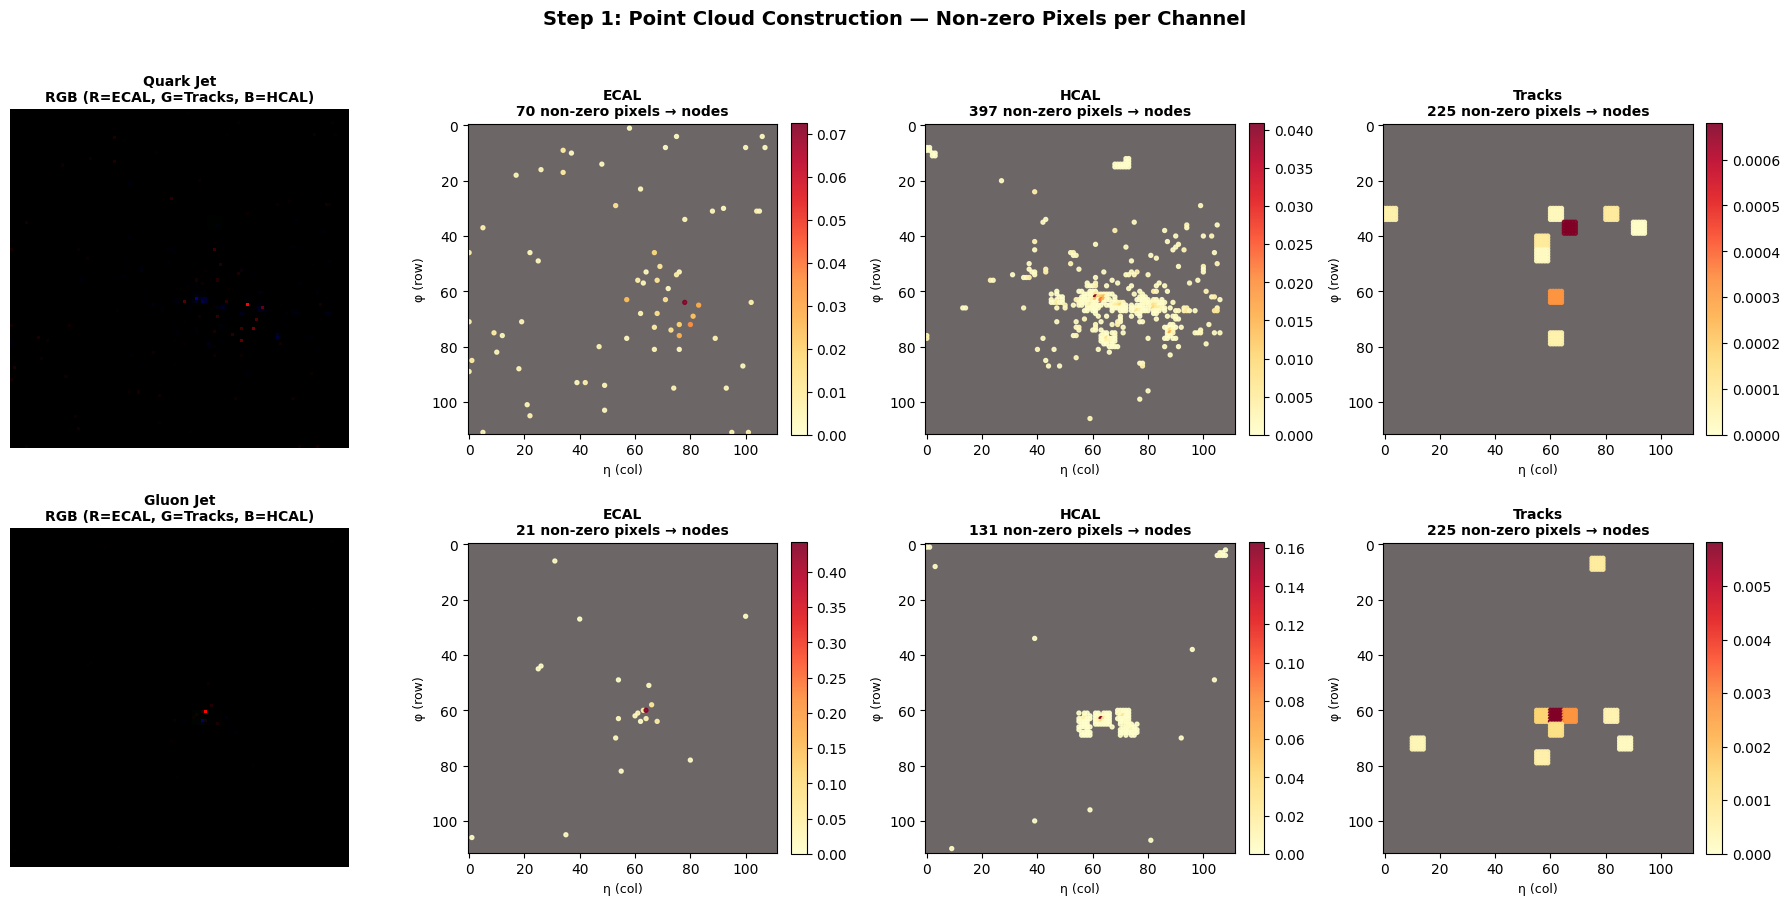

In [12]:
# ── Visualization 1: Point Cloud from raw jet image ─────────────────────────

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
channel_names  = ['ECAL', 'HCAL', 'Tracks']
channel_colors = ['#e74c3c', '#3498db', '#2ecc71']

quark_idx = next(i for i in range(len(labels)) if labels[i] == 0)
gluon_idx = next(i for i in range(len(labels)) if labels[i] == 1)

for row, (idx, jet_type) in enumerate([(quark_idx, 'Quark Jet'),
                                        (gluon_idx, 'Gluon Jet')]):
    sample = data[idx]  
    
    rgb = np.stack([
        sample[0],   # ECAL  → Red
        sample[2],   # Tracks→ Green
        sample[1],   # HCAL  → Blue
    ], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    axes[row, 0].imshow(rgb, origin='upper', aspect='equal')
    axes[row, 0].set_title(f'{jet_type}\nRGB (R=ECAL, G=Tracks, B=HCAL)',
                            fontsize=10, fontweight='bold')
    axes[row, 0].axis('off')

    
    for c, (name, color) in enumerate(zip(channel_names, channel_colors)):
        ax = axes[row, c + 1]
        ch_map = sample[c]

       
        ax.imshow(ch_map, cmap='hot', origin='upper', aspect='equal', alpha=0.6)       
        nz = np.argwhere(ch_map > 0)
        if len(nz) > 0:
            sc = ax.scatter(nz[:, 1], nz[:, 0],
                            c=ch_map[nz[:, 0], nz[:, 1]],
                            cmap='YlOrRd', s=8, alpha=0.9,
                            vmin=0, vmax=ch_map.max())
            plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

        ax.set_title(f'{name}\n{len(nz)} non-zero pixels → nodes',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('η (col)', fontsize=9)
        ax.set_ylabel('φ (row)', fontsize=9)

plt.suptitle('Step 1: Point Cloud Construction — Non-zero Pixels per Channel',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pointcloud_construction.png', dpi=150, bbox_inches='tight')
plt.show()

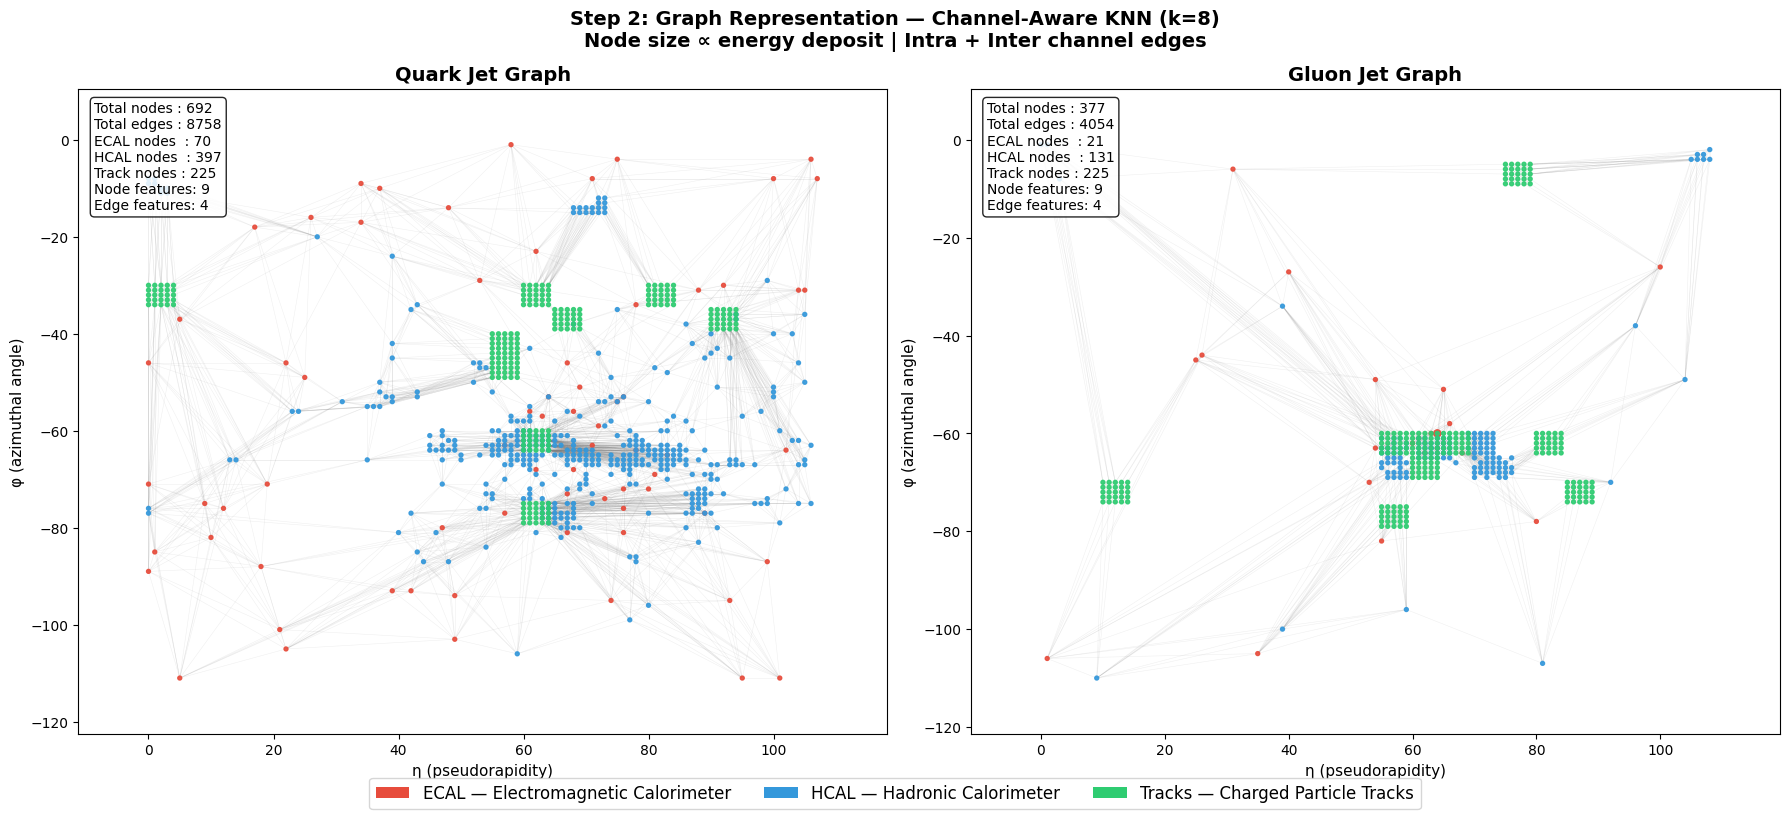

In [21]:
# ── Visualization 2: Graph Structure ────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

quark_g = next(g for g in graph_list if g.y.item() == 0)
gluon_g = next(g for g in graph_list if g.y.item() == 1)

for ax, g, title in zip(axes,
                         [quark_g, gluon_g],
                         ['Quark Jet Graph', 'Gluon Jet Graph']):
    G   = to_networkx(g, to_undirected=True)
    pos = {i: (g.pos[i, 1].item(), -g.pos[i, 0].item())
           for i in range(g.pos.shape[0])}
    
    node_colors, node_sizes = [], []
    for i in range(g.x.shape[0]):
        ch = int(g.x[i, 6:9].argmax().item())
        node_colors.append(['#e74c3c', '#3498db', '#2ecc71'][ch])
        node_sizes.append(max(8, g.x[i, 0].item() * 60))
    
    intra_edges = [(u, v) for u, v in G.edges()
                   if g.edge_attr[
                       ((g.edge_index[0] == u) & (g.edge_index[1] == v)).nonzero(
                           as_tuple=True)[0][0] if
                       len(((g.edge_index[0] == u) & (g.edge_index[1] == v)).nonzero(
                           as_tuple=True)[0]) > 0 else 0, 3
                   ].item() == 1]

    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=G.edges(),
                           alpha=0.12, edge_color='gray', width=0.4)
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors,
                           node_size=node_sizes, alpha=0.9)

    # Stats box
    ecal   = int((g.x[:, 6] == 1).sum())
    hcal   = int((g.x[:, 7] == 1).sum())
    tracks = int((g.x[:, 8] == 1).sum())
    ax.text(0.02, 0.98,
            f'Total nodes : {g.x.shape[0]}\n'
            f'Total edges : {g.edge_index.shape[1]}\n'
            f'ECAL nodes  : {ecal}\n'
            f'HCAL nodes  : {hcal}\n'
            f'Track nodes : {tracks}\n'
            f'Node features: 9\n'
            f'Edge features: 4',
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('η (pseudorapidity)', fontsize=11)
    ax.set_ylabel('φ (azimuthal angle)', fontsize=11)
    ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='ECAL — Electromagnetic Calorimeter'),
    Patch(facecolor='#3498db', label='HCAL — Hadronic Calorimeter'),
    Patch(facecolor='#2ecc71', label='Tracks — Charged Particle Tracks'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, fontsize=12, bbox_to_anchor=(0.5, -0.03))
plt.suptitle('Step 2: Graph Representation — Channel-Aware KNN (k=8)\n'
             'Node size ∝ energy deposit | Intra + Inter channel edges',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('jet_graph_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

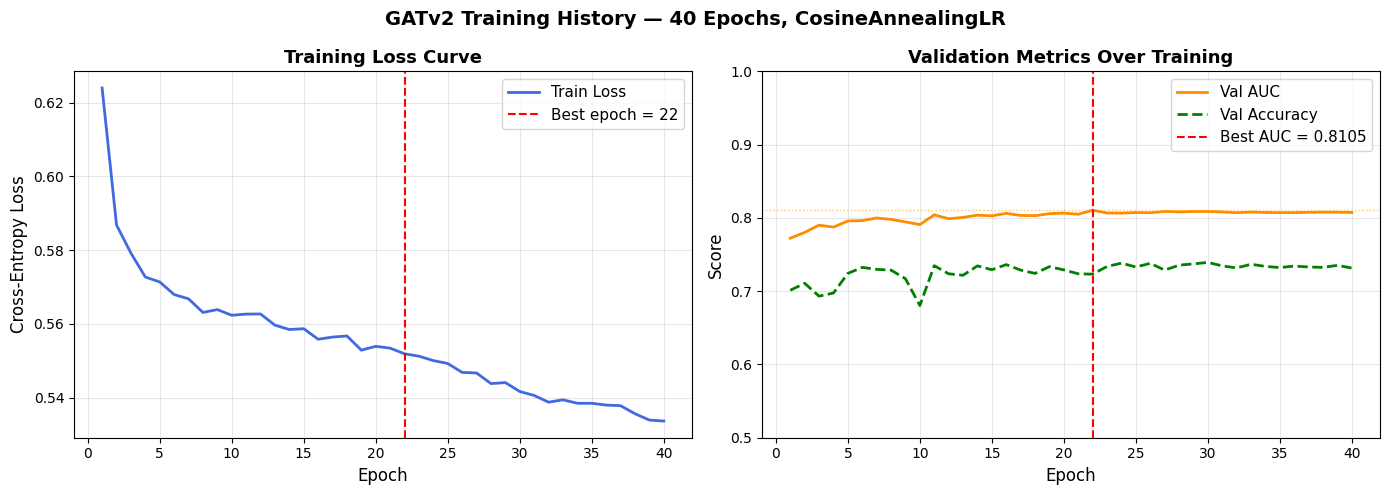

In [22]:
# ── Visualization 3: Training History ───────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_x = range(1, len(train_loss_history) + 1)
best_epoch = int(np.argmax(val_auc_history)) + 1

# Loss curve
ax1.plot(epochs_x, train_loss_history, color='royalblue', lw=2, label='Train Loss')
ax1.axvline(x=best_epoch, color='red', linestyle='--', lw=1.5,
            label=f'Best epoch = {best_epoch}')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax1.set_title('Training Loss Curve', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# AUC + Accuracy curve
ax2.plot(epochs_x, val_auc_history,  color='darkorange', lw=2, label='Val AUC')
ax2.plot(epochs_x, val_acc_history,  color='green', lw=2,
         linestyle='--', label='Val Accuracy')
ax2.axvline(x=best_epoch, color='red', linestyle='--', lw=1.5,
            label=f'Best AUC = {max(val_auc_history):.4f}')
ax2.axhline(y=max(val_auc_history), color='orange', linestyle=':',
            lw=1, alpha=0.6)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Validation Metrics Over Training', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)
ax2.set_ylim(0.5, 1.0)

plt.suptitle('GATv2 Training History — 40 Epochs, CosineAnnealingLR',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

      FINAL TEST RESULTS — GATv2 Classifier
  ROC-AUC               : 0.7919
  Accuracy              : 0.7157
  Avg Precision (PR-AUC): 0.7787
-------------------------------------------------------
              precision    recall  f1-score   support

       Quark       0.77      0.62      0.69      2009
       Gluon       0.68      0.81      0.74      1991

    accuracy                           0.72      4000
   macro avg       0.72      0.72      0.71      4000
weighted avg       0.72      0.72      0.71      4000



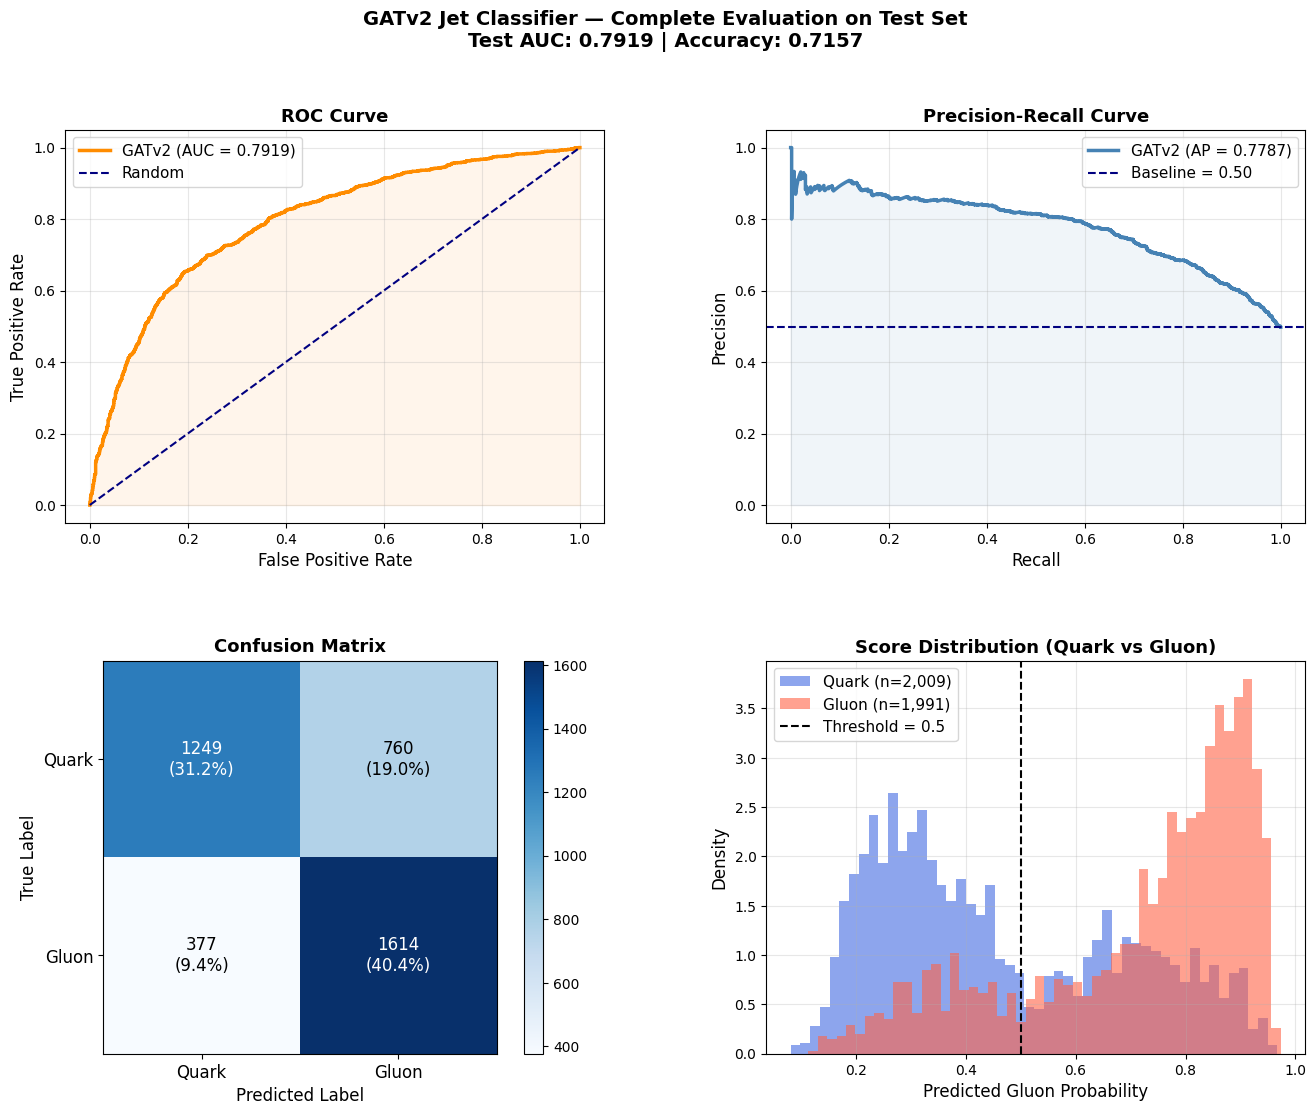

In [23]:
# ── Visualization 4: Full Evaluation Panel ───────────────────────────────────

model.eval()
all_probs_test, all_labels_test = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out   = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        probs = F.softmax(out, dim=1)[:, 1]
        all_probs_test.append(probs.cpu())
        all_labels_test.append(batch.y.cpu())

all_probs_test  = torch.cat(all_probs_test).numpy()
all_labels_test = torch.cat(all_labels_test).numpy()
all_preds_test  = (all_probs_test > 0.5).astype(int)

fpr, tpr, _  = roc_curve(all_labels_test, all_probs_test)
roc_auc      = auc(fpr, tpr)
prec, rec, _ = precision_recall_curve(all_labels_test, all_probs_test)
avg_prec     = average_precision_score(all_labels_test, all_probs_test)
cm           = confusion_matrix(all_labels_test, all_preds_test)

print("=" * 55)
print("      FINAL TEST RESULTS — GATv2 Classifier")
print("=" * 55)
print(f"  ROC-AUC               : {roc_auc:.4f}")
print(f"  Accuracy              : {accuracy_score(all_labels_test, all_preds_test):.4f}")
print(f"  Avg Precision (PR-AUC): {avg_prec:.4f}")
print("-" * 55)
print(classification_report(all_labels_test, all_preds_test,
                             target_names=['Quark', 'Gluon']))
print("=" * 55)

# 4-panel figure
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

# Panel 1: ROC
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(fpr, tpr, color='darkorange', lw=2.5,
         label=f'GATv2 (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], 'navy', lw=1.5, linestyle='--', label='Random')
ax1.fill_between(fpr, tpr, alpha=0.08, color='darkorange')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11); ax1.grid(alpha=0.3)

# Panel 2: Precision-Recall
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(rec, prec, color='steelblue', lw=2.5,
         label=f'GATv2 (AP = {avg_prec:.4f})')
ax2.axhline(y=all_labels_test.mean(), color='navy', linestyle='--',
            label=f'Baseline = {all_labels_test.mean():.2f}')
ax2.fill_between(rec, prec, alpha=0.08, color='steelblue')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11); ax2.grid(alpha=0.3)

# Panel 3: Confusion Matrix
ax3 = fig.add_subplot(gs[1, 0])
im  = ax3.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax3)
ax3.set_xticks([0, 1]); ax3.set_yticks([0, 1])
ax3.set_xticklabels(['Quark', 'Gluon'], fontsize=12)
ax3.set_yticklabels(['Quark', 'Gluon'], fontsize=12)
ax3.set_xlabel('Predicted Label', fontsize=12)
ax3.set_ylabel('True Label', fontsize=12)
ax3.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
for i in range(2):
    for j in range(2):
        ax3.text(j, i, f'{cm[i,j]}\n({cm[i,j]/cm.sum()*100:.1f}%)',
                 ha='center', va='center', fontsize=12,
                 color='white' if cm[i,j] > cm.max()/2 else 'black')

# Panel 4: Score Distribution
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(all_probs_test[all_labels_test == 0], bins=50,
         alpha=0.6, color='royalblue', density=True,
         label=f'Quark (n={int((all_labels_test==0).sum()):,})')
ax4.hist(all_probs_test[all_labels_test == 1], bins=50,
         alpha=0.6, color='tomato', density=True,
         label=f'Gluon (n={int((all_labels_test==1).sum()):,})')
ax4.axvline(x=0.5, color='black', linestyle='--', lw=1.5, label='Threshold = 0.5')
ax4.set_xlabel('Predicted Gluon Probability', fontsize=12)
ax4.set_ylabel('Density', fontsize=12)
ax4.set_title('Score Distribution (Quark vs Gluon)', fontsize=13, fontweight='bold')
ax4.legend(fontsize=11); ax4.grid(alpha=0.3)

plt.suptitle('GATv2 Jet Classifier — Complete Evaluation on Test Set\n'
             f'Test AUC: {roc_auc:.4f} | Accuracy: {accuracy_score(all_labels_test, all_preds_test):.4f}',
             fontsize=14, fontweight='bold')
plt.savefig('gatv2_full_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()